In [ ]:
import zipfile, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import boxcox
from sklearn.metrics import mean_absolute_error as MAE, r2_score as R2

## 1. Подготовка данных. Загрузка. Графики

In [ ]:
!wget 'https://github.com/AndrDFg/Homework.-Netology.-Data-Science/raw/refs/heads/main/13.%20Временные%20ряды/ДЗ_1_Временные%20ряды,%20общая%20теория/time_series6_csv.zip' -O time_series_csv.zip

--2025-08-15 15:29:29--  https://github.com/AndrDFg/Homework.-Netology.-Data-Science/raw/refs/heads/main/13.%20%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%80%D1%8F%D0%B4%D1%8B/%D0%94%D0%97_1_%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%80%D1%8F%D0%B4%D1%8B,%20%D0%BE%D0%B1%D1%89%D0%B0%D1%8F%20%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F/time_series6_csv.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AndrDFg/Homework.-Netology.-Data-Science/refs/heads/main/13.%20%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%80%D1%8F%D0%B4%D1%8B/%D0%94%D0%97_1_%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%80%D1%8F%D0%B4%D1%8B%2C%20%D0%BE%D0%B1%D1%89%D0%B0%D1%8F%20%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F/time_series6_csv.zip [following]
--2025-08-15 15:29:29--  https://raw.githubuserconte

In [ ]:
# Содержимое архива
with zipfile.ZipFile(file='/content/time_series_csv.zip') as my_zip:
  fileslist = [file.filename for file in my_zip.filelist]
print('Содержимое архива')
fileslist

Содержимое архива


['mean-monthly-air-temperature-deg.csv',
 'monthly-boston-armed-robberies-j.csv',
 'monthly-sales-of-company-x-jan-6.csv',
 'weekly-closings-of-the-dowjones-.csv',
 'daily-total-female-births-in-cal.csv',
 'international-airline-passengers.csv']

In [ ]:
# Распаковываем отдельный файл, где явно прослеживается сезонность и тренд
with zipfile.ZipFile(file='/content/time_series_csv.zip') as data_files:
  data_files.extract(member='international-airline-passengers.csv')

In [ ]:
data_airline = pd.read_csv(filepath_or_buffer='international-airline-passengers.csv', sep=',')
data_airline.head(3)

,Month,Count
0,1949-01,112
1,1949-02,118
2,1949-03,132


In [ ]:
# Формирование Series с индексом типа date_range
date_index = pd.date_range(start='1949', periods=data_airline.shape[0], freq='ME')
data_airline_series = pd.Series(data=data_airline['Count'].values, index=date_index, name='Count')
data_airline_series.head()

,Count
1949-01-31,112
1949-02-28,118
1949-03-31,132
1949-04-30,129
1949-05-31,121


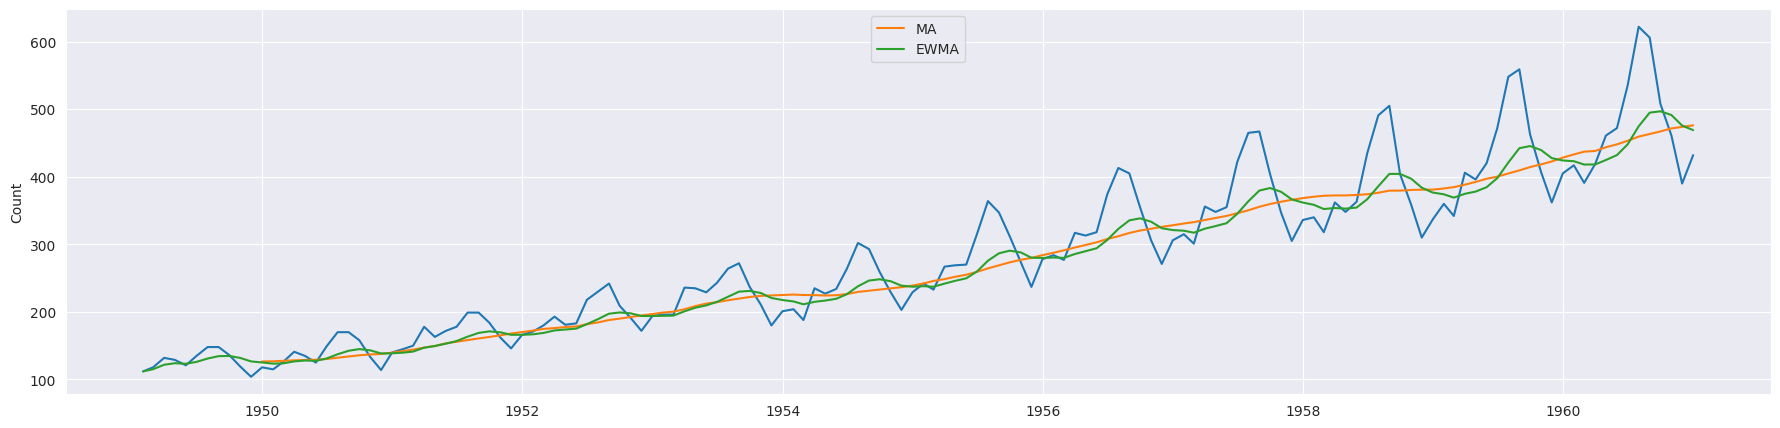

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize=(22, 5))
sns.lineplot(data_airline_series)
sns.lineplot(data_airline_series.rolling(12).mean(), label='MA')
sns.lineplot(data_airline_series.ewm(span=12).mean(), label='EWMA')
plt.legend(loc='upper center')
plt.show()

## 2. Построение модели ARIMA

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.graphics.tsaplots import plot_acf          # график автокорреляционной функции (ACF) показывает корреляцию временного ряда с самим собой, но сдвинутым на определенное количество периодов (лагов).
from statsmodels.graphics.tsaplots import plot_pacf         # график частичной автокорелляции (PACF) измеряет корреляцию между наблюдениями с разными лагами после устранения влияния наблюдений с промежуточными лагами.

In [ ]:
#  ADF-тест (тест Дики-Фуллера). Проверка стационарности + Графики автокорреляции
def test_fuller_tsaplots(series_, lag=12):
  result_test_fuller = adfuller(series_)
  if result_test_fuller[1] < 0.05:
    print('Временной ряд стационарный')
  else:
    print('Временной ряд не стационарный. Требуется обработка')
  print(f'ADf_статистика: {result_test_fuller[0]:.5f}\nP_value: {result_test_fuller[1]:.5f}')
  figura, ax = plt.subplots(ncols=1, nrows=2, figsize=(18, 5))
  plot_acf(series_, lags=lag, ax=ax[0])
  ax[0].set_title('Автокорреляционная функция (ACF)')
  plot_pacf(series_, lags=lag, ax=ax[1])
  ax[1].set_title('Частная автокорреляционная функция (PACF)')
  plt.tight_layout()
  plt.show()

### Разделение временного ряда на обучающую и тестовую выборки

In [ ]:
coef_size = 0.8
train_size = int(len(data_airline_series) * coef_size)
print(f'Размер обучающей выборки: {train_size}')

Размер обучающей выборки: 115


In [ ]:
train, test = data_airline_series[:train_size], data_airline_series[train_size:]
print(f'Обучающая выборка: {train.shape}\nТестовая выборка: {test.shape}\nИтог: {len(train)+len(test)}\nПроверка суммы: {len(data_airline_series)}')

Обучающая выборка: (115,)
Тестовая выборка: (29,)
Итог: 144
Проверка суммы: 144


Временной ряд не стационарный. Требуется обработка
ADf_статистика: -0.35689
P_value: 0.91705


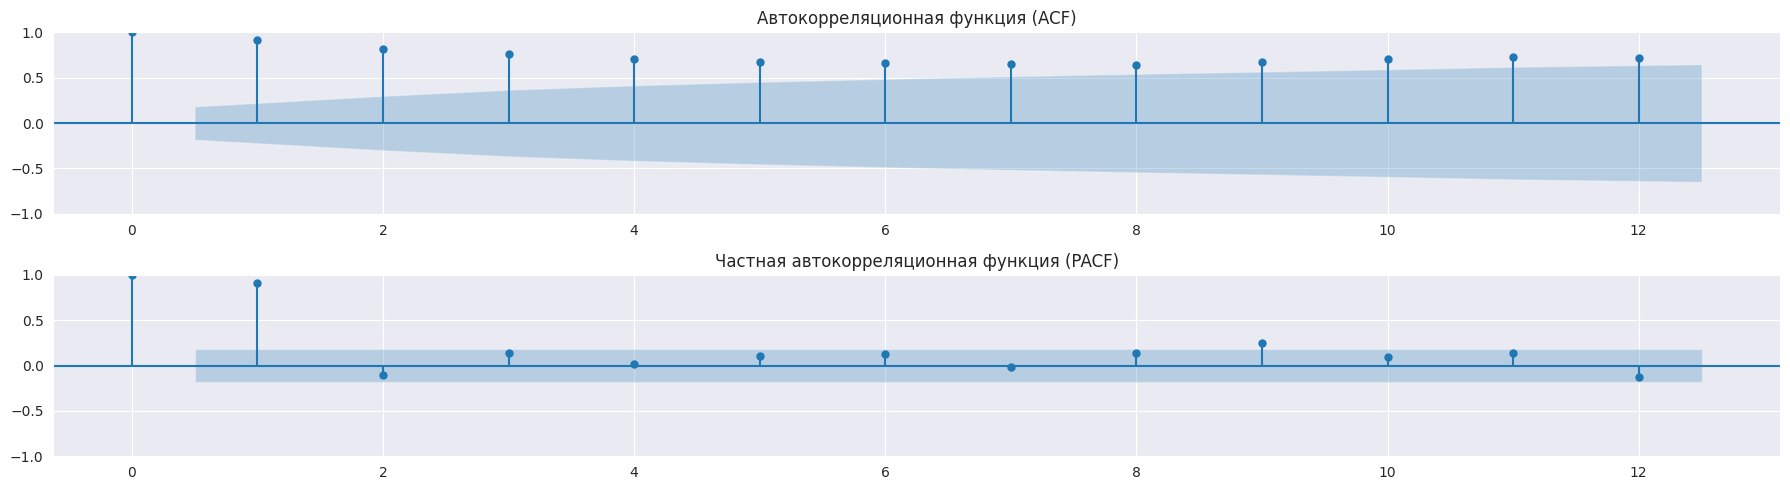

In [ ]:
# Исходный временной ряд (обучающая выборка)
test_fuller_tsaplots(train)

In [ ]:
# Порядок (период) дифференцирования
period_diff = 2

Временной ряд не стационарный. Требуется обработка
ADf_статистика: -2.35597
P_value: 0.15455


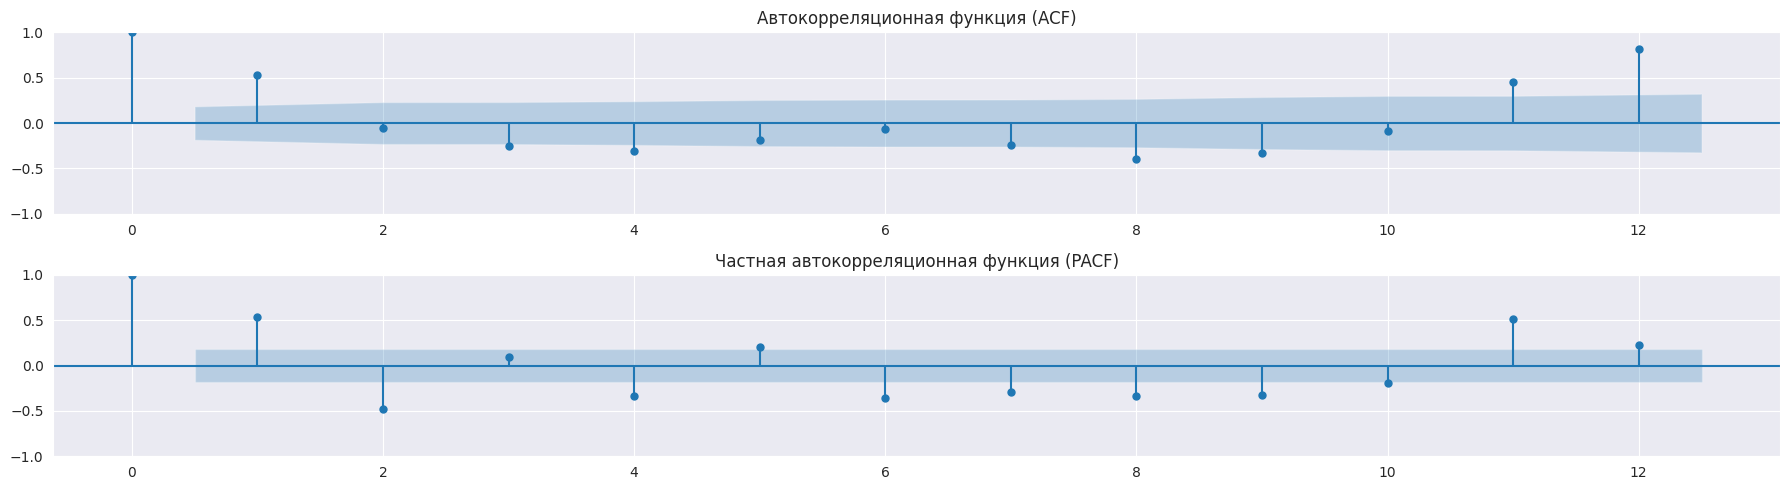

In [ ]:
# Повторный тест проверка стационарности ряда обучающей выборки
test_fuller_tsaplots(train.diff(period_diff).dropna())

In [ ]:
# РУЧНОЙ ПОДБОР ПАРАМЕТРОВ МОДЕЛИ
p = 13                                          # p - порядок авторегрессии (AR) - анализируем PACF
d = period_diff                                 # d - порядок интеграции - определяется необходимым дифференцированием
q = 13                                          # q - порядок скользящего среднего (MA) - анализируем ACF

manual_settings_order = (p, d, q)
MODEL_ARIMA = ARIMA(endog=train, order=manual_settings_order)

In [ ]:
# Обучение модели
fit_model = MODEL_ARIMA.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Сумарная информация о модели
print(fit_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Count   No. Observations:                  115
Model:               ARIMA(13, 2, 13)   Log Likelihood                -413.647
Date:                Fri, 15 Aug 2025   AIC                            881.295
Time:                        15:29:33   BIC                            954.934
Sample:                    01-31-1949   HQIC                           911.177
                         - 07-31-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6044      0.495     -1.220      0.222      -1.575       0.366
ar.L2         -0.1336      0.729     -0.183      0.855      -1.562       1.294
ar.L3         -0.0722      0.748     -0.096      0.9

## 3. Построение график остатков (обученной и тестовой выборок)

Временной ряд стационарный
ADf_статистика: -20.81493
P_value: 0.00000


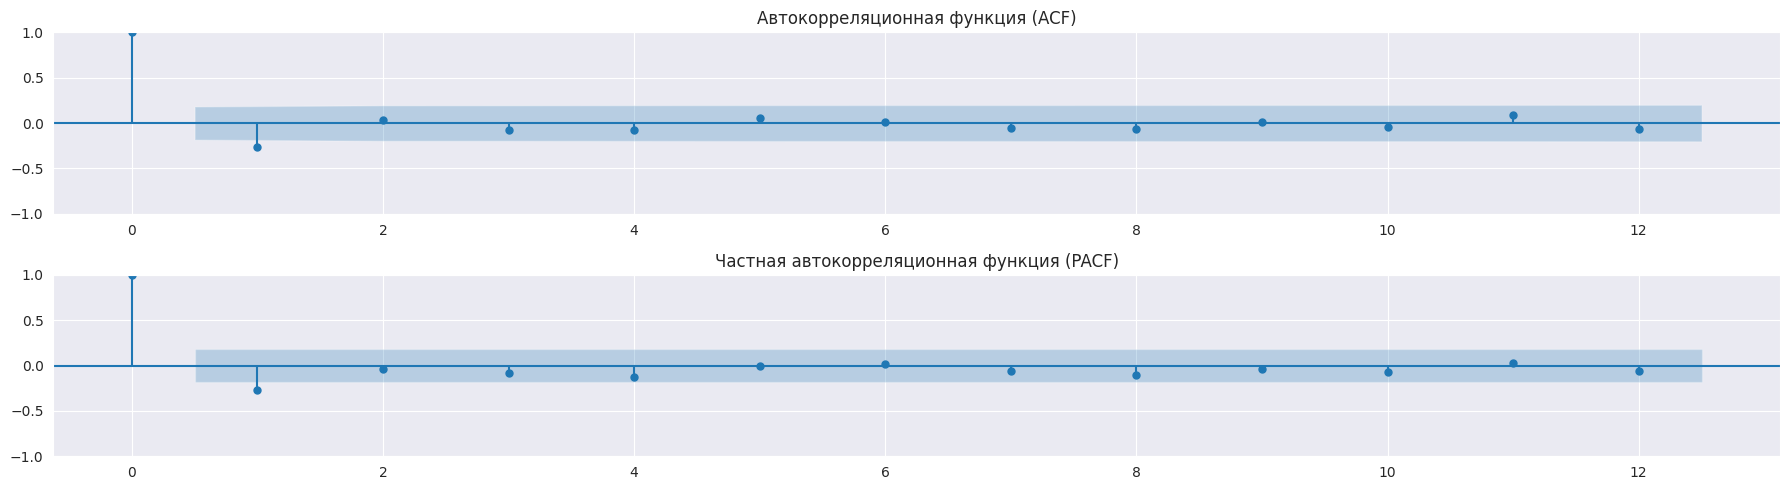

In [ ]:
# ОСТАТКИ ОБУЧАЮЩЕЙ ВЫБОРКИ
test_fuller_tsaplots(fit_model.resid)

In [ ]:
#Расчёт прогноза
predict_forecast = fit_model.forecast(steps=len(test))
series_forecast = pd.Series(data=predict_forecast, index=test.index)

In [ ]:
# Расчёт остатков тестовой выборки
reside_test = test-series_forecast

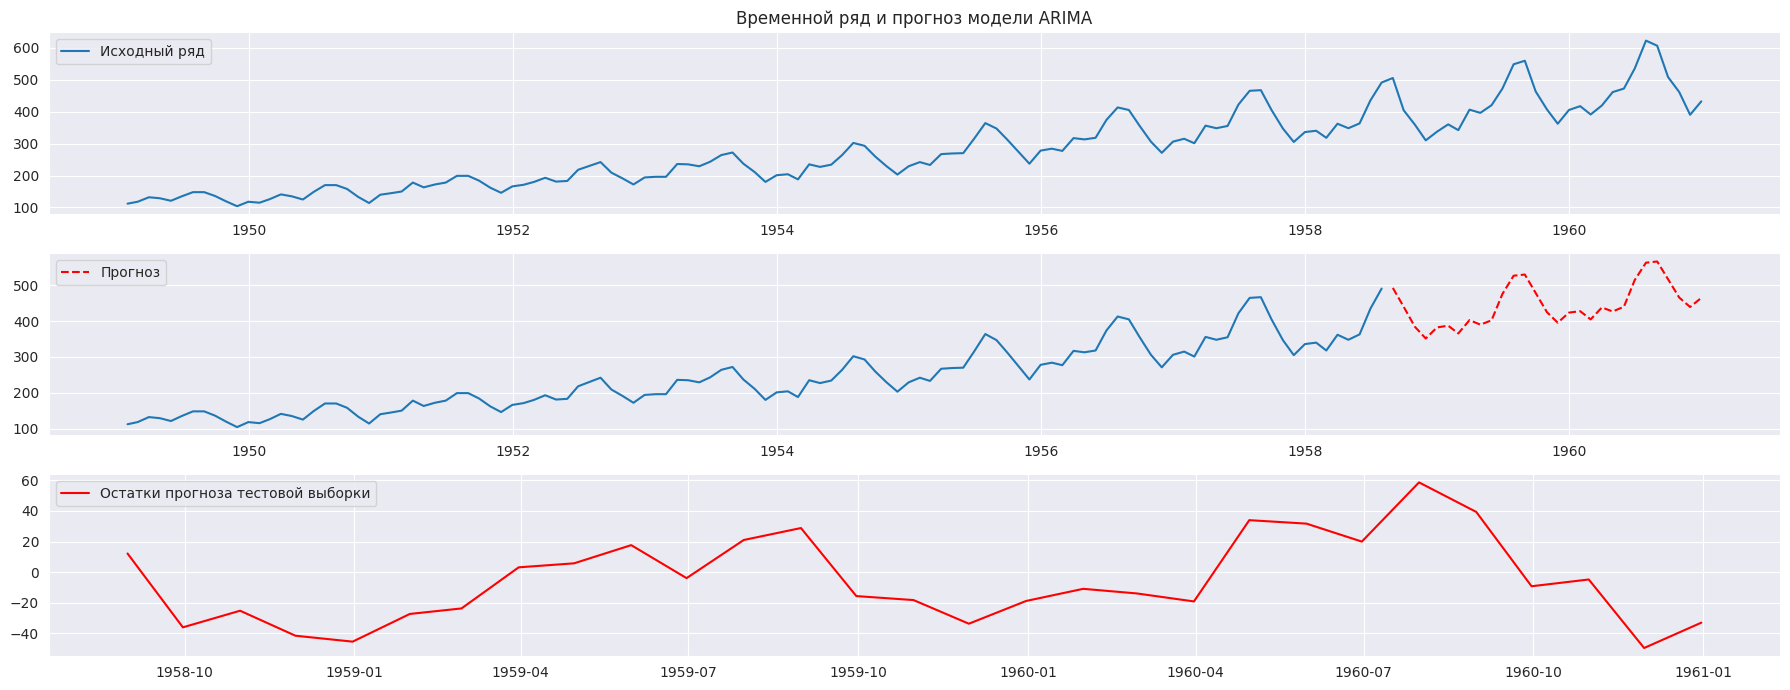

In [ ]:
figure, ax = plt.subplots(ncols=1, nrows=3, figsize=(18, 7))
ax[0].set_title('Временной ряд и прогноз модели ARIMA')
ax[0].plot(data_airline_series, label='Исходный ряд')
ax[0].legend()

ax[1].plot(train)
ax[1].plot(series_forecast, 'r--', label='Прогноз')
ax[1].legend()

ax[2].plot(reside_test, color='r', linestyle='-', label='Остатки прогноза тестовой выборки')
ax[2].legend(loc='best')

plt.tight_layout()
plt.show()


Временной ряд стационарный
ADf_статистика: -3.45978
P_value: 0.00908


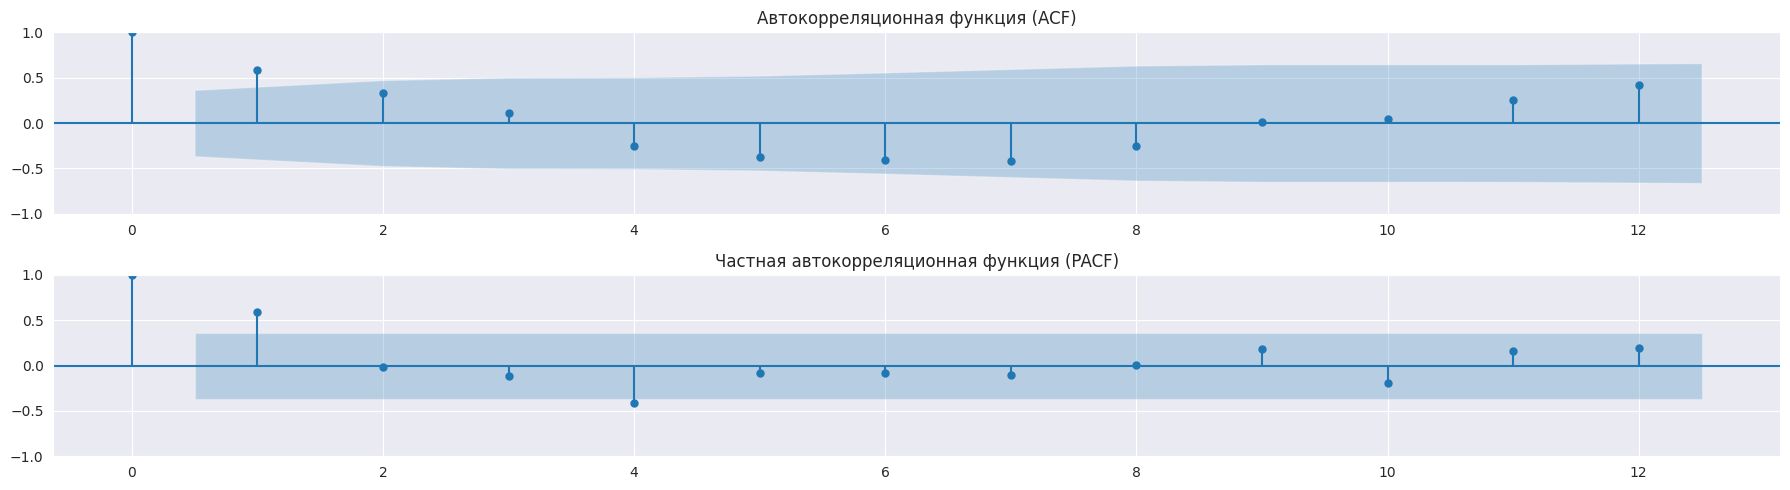

In [ ]:
# ОСТАТКИ ТЕСТОВОЙ ВЫБОРКИ
test_fuller_tsaplots(reside_test)

In [ ]:
mae = MAE(y_true=test, y_pred=series_forecast)
r2 = R2(y_true=test, y_pred=series_forecast)

In [ ]:
metrics_model = pd.DataFrame(data={'MAE': [mae], 'R2': [r2]}, index=['ARIMA'])
metrics_model

,MAE,R2
ARIMA,24.222884,0.871329
